In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
%config InlineBackend.figure_format = "svg"

In [3]:
font_names = [f.name for f in font_manager.fontManager.ttflist]
if 'Arial' in font_names:
    print("'Arial' font is available.")
else:
    print("'Arial' font is not available. Please ensure it's installed on your system.")

'Arial' font is available.


In [ ]:
sns.set_theme(font='Arial')
plt.rcParams['svg.fonttype'] = 'none'


Import partition coefficients data

In [ ]:
part_coeff_df = pd.read_csv('./Data/MAIN_episuite_data.tsv', sep='\t', dtype=str)
part_coeff_df = part_coeff_df.replace(np.nan, '', regex=True)
print(part_coeff_df.shape)
part_coeff_df.head()

(230, 12)


,id,pubchemid,casrn,predicted_log_kow,experimental_log_kow,predicted_log_kaw,predicted_log_koa,experimental_log_koa,bioconcentration_factor,bioaccumulation_factor,volatilization_halflife_in_hours_lake_model,volatilization_halflife_in_hours_river_model
0,RID00230,CID:54675779,CAS:79-57-2,-2.866900086402893,-0.9,-23.15697343523684,22.25697343523684,,3.16,0.9,8.043269625808533e+22,7.372997166978994e+21
1,RID00262,CID:637566,CAS:106-24-1,3.4699999392032623,3.56,-2.6039509214256342,6.163950921425634,,103.73,223.58,248.27804422051193,13.211499838790058
2,RID00012,CID:10286,CAS:491-38-3,1.7440999150276184,1.38,-4.481936537464587,5.861936537464587,,0.98,3.27,9691.204695954737,879.0673771598106
3,RID00071,CID:197810,CAS:476-32-4,2.911500036716461,,-15.820927239788578,18.73242727650504,,38.73,4.28,3250250047598049.0,297939588100077.56
4,RID00231,CID:54675783,CAS:10118-90-8,-0.4172000288963318,0.05,-22.204828818457262,22.254828818457263,,3.16,0.91,8.951353163726836e+21,8.205407077865062e+20


In [8]:
part_coeff_df.columns = ['ID', 'PubChemID', 'CAS', 'Predicted Log Kow', 'Experimental Log Kow', 
                          'Predicted Log Kaw', 'Predicted Log Koa', 'Experimental Log Koa',
                          'Bioconcentration Factor (L/kg wet-wt)', 'Bioaccumulation Factor (L/kg wet-wt)',
                          'Volatilization Half-Life in Hours (Lake Model)',
       'Volatilization Half-Life in Hours (River Model)']
print(part_coeff_df.shape)
part_coeff_df.head()

(230, 12)


,ID,PubChemID,CAS,Predicted Log Kow,Experimental Log Kow,Predicted Log Kaw,Predicted Log Koa,Experimental Log Koa,Bioconcentration Factor (L/kg wet-wt),Bioaccumulation Factor (L/kg wet-wt),Volatilization Half-Life in Hours (Lake Model),Volatilization Half-Life in Hours (River Model)
0,RID00230,CID:54675779,CAS:79-57-2,-2.866900086402893,-0.9,-23.15697343523684,22.25697343523684,,3.16,0.9,8.043269625808533e+22,7.372997166978994e+21
1,RID00262,CID:637566,CAS:106-24-1,3.4699999392032623,3.56,-2.6039509214256342,6.163950921425634,,103.73,223.58,248.27804422051193,13.211499838790058
2,RID00012,CID:10286,CAS:491-38-3,1.7440999150276184,1.38,-4.481936537464587,5.861936537464587,,0.98,3.27,9691.204695954737,879.0673771598106
3,RID00071,CID:197810,CAS:476-32-4,2.911500036716461,,-15.820927239788578,18.73242727650504,,38.73,4.28,3250250047598049.0,297939588100077.56
4,RID00231,CID:54675783,CAS:10118-90-8,-0.4172000288963318,0.05,-22.204828818457262,22.254828818457263,,3.16,0.91,8.951353163726836e+21,8.205407077865062e+20


In [9]:
part_coeff_df['Final log Kow'] = part_coeff_df.apply(lambda row: row['Experimental Log Kow'] if row['Experimental Log Kow'] != '' else row['Predicted Log Kow'], axis=1)
print(part_coeff_df.shape)
part_coeff_df.head()

(230, 13)


,ID,PubChemID,CAS,Predicted Log Kow,Experimental Log Kow,Predicted Log Kaw,Predicted Log Koa,Experimental Log Koa,Bioconcentration Factor (L/kg wet-wt),Bioaccumulation Factor (L/kg wet-wt),Volatilization Half-Life in Hours (Lake Model),Volatilization Half-Life in Hours (River Model),Final log Kow
0,RID00230,CID:54675779,CAS:79-57-2,-2.866900086402893,-0.9,-23.15697343523684,22.25697343523684,,3.16,0.9,8.043269625808533e+22,7.372997166978994e+21,-0.9
1,RID00262,CID:637566,CAS:106-24-1,3.4699999392032623,3.56,-2.6039509214256342,6.163950921425634,,103.73,223.58,248.27804422051193,13.211499838790058,3.56
2,RID00012,CID:10286,CAS:491-38-3,1.7440999150276184,1.38,-4.481936537464587,5.861936537464587,,0.98,3.27,9691.204695954737,879.0673771598106,1.38
3,RID00071,CID:197810,CAS:476-32-4,2.911500036716461,,-15.820927239788578,18.73242727650504,,38.73,4.28,3250250047598049.0,297939588100077.56,2.911500036716461
4,RID00231,CID:54675783,CAS:10118-90-8,-0.4172000288963318,0.05,-22.204828818457262,22.254828818457263,,3.16,0.91,8.951353163726836e+21,8.205407077865062e+20,0.05


In [10]:
part_coeff_df['Final log Koa'] = part_coeff_df.apply(lambda row: row['Experimental Log Koa'] if row['Experimental Log Koa'] != '' else row['Predicted Log Koa'], axis=1)
print(part_coeff_df.shape)
part_coeff_df.head()

(230, 14)


,ID,PubChemID,CAS,Predicted Log Kow,Experimental Log Kow,Predicted Log Kaw,Predicted Log Koa,Experimental Log Koa,Bioconcentration Factor (L/kg wet-wt),Bioaccumulation Factor (L/kg wet-wt),Volatilization Half-Life in Hours (Lake Model),Volatilization Half-Life in Hours (River Model),Final log Kow,Final log Koa
0,RID00230,CID:54675779,CAS:79-57-2,-2.866900086402893,-0.9,-23.15697343523684,22.25697343523684,,3.16,0.9,8.043269625808533e+22,7.372997166978994e+21,-0.9,22.25697343523684
1,RID00262,CID:637566,CAS:106-24-1,3.4699999392032623,3.56,-2.6039509214256342,6.163950921425634,,103.73,223.58,248.27804422051193,13.211499838790058,3.56,6.163950921425634
2,RID00012,CID:10286,CAS:491-38-3,1.7440999150276184,1.38,-4.481936537464587,5.861936537464587,,0.98,3.27,9691.204695954737,879.0673771598106,1.38,5.861936537464587
3,RID00071,CID:197810,CAS:476-32-4,2.911500036716461,,-15.820927239788578,18.73242727650504,,38.73,4.28,3250250047598049.0,297939588100077.56,2.911500036716461,18.73242727650504
4,RID00231,CID:54675783,CAS:10118-90-8,-0.4172000288963318,0.05,-22.204828818457262,22.254828818457263,,3.16,0.91,8.951353163726836e+21,8.205407077865062e+20,0.05,22.254828818457263


In [ ]:
part_coeff_df['Final log Kow'] = part_coeff_df['Final log Kow'].astype(float)
part_coeff_df['Predicted Log Kaw'] = part_coeff_df['Predicted Log Kaw'].astype(float)
part_coeff_df['Final log Koa'] = part_coeff_df['Final log Koa'].astype(float)
part_coeff_df['Bioconcentration Factor (L/kg wet-wt)'] = part_coeff_df['Bioconcentration Factor (L/kg wet-wt)'].astype(float)
part_coeff_df['Bioaccumulation Factor (L/kg wet-wt)'] = part_coeff_df['Bioaccumulation Factor (L/kg wet-wt)'].astype(float)

In [ ]:
logKow = list(part_coeff_df['Final log Kow'])
logKaw = list(part_coeff_df['Predicted Log Kaw'])
logKoa = list(part_coeff_df['Final log Koa']) 
bcf = list(part_coeff_df['Bioconcentration Factor (L/kg wet-wt)'])
baf = list(part_coeff_df['Bioaccumulation Factor (L/kg wet-wt)'])

Import solubility data

In [ ]:
aqsoldb = pd.read_csv('./Data/MAIN_aqsoldb_data.tsv', sep='\t', dtype=str)
aqsoldb = aqsoldb.replace(np.nan, '', regex=True)
print(aqsoldb.shape)
aqsoldb.head()

(102, 5)


,id,pubchemid,casrn,solubility_logs,standard_deviation
0,RID00118,CID:323,CAS:91-64-5,-1.8860303607,0.6405071007775657
1,RID00047,CID:14778,CAS:1305-78-8,-1.7683268794999998,0.8662676474479235
2,RID00299,CID:702,CAS:64-17-5,1.2336682179,0.09686284934141773
3,RID00262,CID:637566,CAS:106-24-1,-2.3519095035,0.41816205785000005
4,RID00151,CID:440917,CAS:5989-27-5,-4.346837785,0.17426641779787772


In [ ]:
print(len(set(part_coeff_df['ID'])))
print(len(set(aqsoldb['id'])))
print(len(set(part_coeff_df['ID']).intersection(set(aqsoldb['id']))))

230
102
90


In [ ]:
aqsoldb['solubility_logs'] = aqsoldb['solubility_logs'].astype(float)
print(aqsoldb.shape)
aqsoldb.head()

(102, 5)


,id,pubchemid,casrn,solubility_logs,standard_deviation
0,RID00118,CID:323,CAS:91-64-5,-1.886030,0.6405071007775657
1,RID00047,CID:14778,CAS:1305-78-8,-1.768327,0.8662676474479235
2,RID00299,CID:702,CAS:64-17-5,1.233668,0.09686284934141773
3,RID00262,CID:637566,CAS:106-24-1,-2.351910,0.41816205785000005
4,RID00151,CID:440917,CAS:5989-27-5,-4.346838,0.17426641779787772


In [ ]:
print(aqsoldb["solubility_logs"].min())
print(aqsoldb["solubility_logs"].max())

-8.4024
1.3647745033


Plot

In [ ]:
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'

figsize_inches = (16 / 2.54, 15 / 2.54)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic"
})

cmap1 = sns.cubehelix_palette(start=0.5, rot=-0.5, dark=0.1, light=0.5, reverse=True, as_cmap=True)
cmap2 = sns.cubehelix_palette(start=2.0, rot=0,    dark=0.2, light=0.9, reverse=True, as_cmap=True)
cmap3 = sns.cubehelix_palette(start=0,   rot=0.5,  dark=0.2, light=0.9, reverse=True, as_cmap=True)

fig, axes = plt.subplots(2, 2, figsize=figsize_inches)

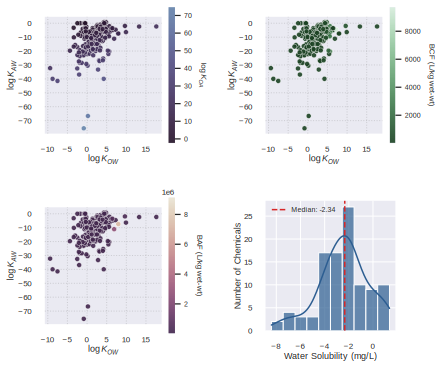

In [ ]:
plot_configs = [
    (axes[0, 0], r"$\log K_{OA}$", logKoa, cmap1),     
    (axes[0, 1], "BCF (L/kg wet-wt)", bcf, cmap2), 
    (axes[1, 0], "BAF (L/kg wet-wt)", baf, cmap3)  
]

for ax, label, color_data, palette in plot_configs:
    ax.set_box_aspect(1) # Makes plots square
    ax.grid(True, linestyle=':', alpha=0.3, color='gray', zorder=0)
    
    sc = ax.scatter(
        logKow, logKaw, 
        c=color_data, cmap=palette,
        s=25, edgecolor="white", linewidth=0.4, alpha=0.9, zorder=3
    )

    ax.set_xlabel(r"$\log K_{OW}$", labelpad=2)
    ax.set_ylabel(r"$\log K_{AW}$", labelpad=2)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label(label, rotation=270, labelpad=15, fontsize=8)
    cbar.outline.set_visible(False)
    cax.tick_params(labelsize=7)
    
    sns.despine(ax=ax, trim=True, offset=3)

ax_hist = axes[1, 1]
ax_hist.set_box_aspect(1)
median_val = aqsoldb["solubility_logs"].median()
hist_color = sns.cubehelix_palette(start=1.2, rot=0, dark=0.4, light=.8)[2]

sns.histplot(
    data=aqsoldb, x="solubility_logs", kde=True, 
    color="#2c5d91", ax=ax_hist, edgecolor="white", alpha=0.7
)

ax_hist.axvline(
    median_val, linestyle="--", color='#d62728', 
    linewidth=1.5, label=f"Median: {median_val:.2f}"
)

ax_hist.set_xlabel("Water Solubility (mg/L)", labelpad=2)
ax_hist.set_ylabel("Number of Chemicals", labelpad=2)
ax_hist.legend(frameon=False, fontsize=7)

sns.despine(ax=ax_hist, trim=True, offset=3)

plt.subplots_adjust(wspace=0.7, hspace=0.4) 

plt.savefig("../Output/fig_combined_modified.svg", format='svg', bbox_inches='tight')
plt.show()